# 🛍️ Shopping Mall Customer Segmentation
## Member X — Gaussian Mixture Model (GMM)
**Dataset:** Shopping_Mall_Customer_Segmentation_Data_.csv  
**Algorithm:** Gaussian Mixture Model (GMM)  
**Task:** Unsupervised Learning — Customer Segmentation

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score

import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## 2. Load Pre-processed Data
> Data was already cleaned and scaled in `step0_eda_preprocessing_no_pca.ipynb`.
> This GMM version uses **scaled features directly** without PCA.


In [2]:
import numpy as np
import pandas as pd

# 加载你 step0 处理好的完整数据
df = pd.read_csv('data/data_full_preprocessed.csv')
print(f"数据加载成功，当前共有 {df.shape[0]} 条记录")

数据加载成功，当前共有 15079 条记录


In [3]:
# 1. 自动抓取所有分箱列，但排除掉 Age_Group 这个字符串列
# 确保只选取数值型（0/1）的分箱特征
age_bin_cols = [col for col in df.columns if col.startswith('Age_') and col != 'Age_Group']

# 2. 定义最终参与聚类的特征列表
# 这里的 'Gender_Enum' 对应你在 step0 里 map 好的 0/1 数值
features_to_use = ['Gender_Enum', 'Annual Income', 'Spending Score'] + age_bin_cols

# 3. 提取矩阵
X = df[features_to_use]

# --- 检查区：如果打印出来有 object 类型，说明还是选错了 ---
print("参与模型的特征列:", X.columns.tolist())
print("数据类型检查:\n", X.dtypes)

# 4. 标准化 (这里就不会再报 String to Float 的错误了)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('\n✅ 特征矩阵准备就绪，形状:', X_scaled.shape)

参与模型的特征列: ['Gender_Enum', 'Annual Income', 'Spending Score', 'Age_Bin_<20', 'Age_Bin_20-25', 'Age_Bin_25-30', 'Age_Bin_30-35', 'Age_Bin_35-40', 'Age_Bin_40-45', 'Age_Bin_45-50', 'Age_Bin_50-55', 'Age_Bin_55-60', 'Age_Bin_>60']
数据类型检查:
 Gender_Enum       int64
Annual Income     int64
Spending Score    int64
Age_Bin_<20       int64
Age_Bin_20-25     int64
Age_Bin_25-30     int64
Age_Bin_30-35     int64
Age_Bin_35-40     int64
Age_Bin_40-45     int64
Age_Bin_45-50     int64
Age_Bin_50-55     int64
Age_Bin_55-60     int64
Age_Bin_>60       int64
dtype: object

✅ 特征矩阵准备就绪，形状: (15079, 13)


## 3. Select Optimal Number of Clusters (BIC)
> GMM does not use bandwidth like MeanShift.  
> Instead, we test different values of **K** and choose the best one using **BIC** (lower is better).


In [4]:
bic_scores = []
aic_scores = []
k_range = range(2, 10)

for k in k_range:
    model = GaussianMixture(
        n_components=k,
        covariance_type='diag',
        random_state=42,
        n_init=5
    )
    model.fit(X_scaled)
    bic_scores.append(model.bic(X_scaled))
    aic_scores.append(model.aic(X_scaled))

best_k = list(k_range)[np.argmin(bic_scores)]
print(f'✅ Best K selected by BIC: {best_k}')

✅ Best K selected by BIC: 9


In [5]:
best_k = 4

## 4. BIC / AIC Visualization

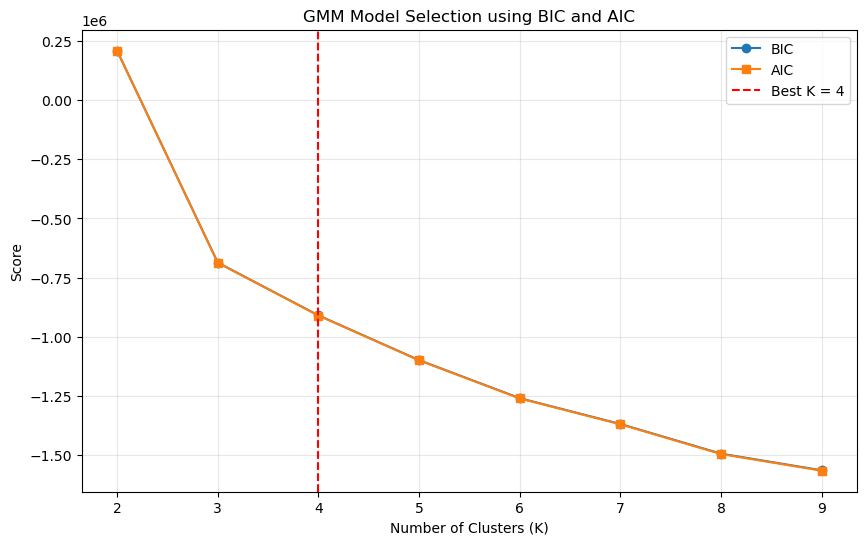

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), bic_scores, marker='o', label='BIC')
plt.plot(list(k_range), aic_scores, marker='s', label='AIC')
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')

plt.title('GMM Model Selection using BIC and AIC')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Score')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 5. Train GMM Model
> Train the final Gaussian Mixture Model using the selected number of clusters.


In [7]:
gmm = GaussianMixture(
    n_components=best_k,
    covariance_type='diag',
    random_state=42,
    n_init=5
)
gmm.fit(X_scaled)

cluster_labels = gmm.predict(X_scaled)
cluster_probs = gmm.predict_proba(X_scaled)
df_clean['Cluster'] = cluster_labels
n_clusters = len(np.unique(cluster_labels))

print(f'Number of clusters found by GMM: {n_clusters}')
print('\nCluster Distribution:')
unique, counts = np.unique(cluster_labels, return_counts=True)
for c, cnt in zip(unique, counts):
    print(f'  Cluster {c}: {cnt} customers ({cnt/len(df)*100:.1f}%)')

df_clean['Cluster'] = cluster_labels
df['Cluster'] = cluster_labels

NameError: name 'df_clean' is not defined

## 6. Evaluation Metrics

In [ ]:
import pandas as pd
import pickle
# Evaluation metrics
sil = silhouette_score(X_scaled, cluster_labels)
dbi = davies_bouldin_score(X_scaled, cluster_labels)

print('=' * 72)
print('                GMM EVALUATION METRICS')
print('=' * 72)
print(f'  Algorithm                 : Gaussian Mixture Model (GMM)')
print(f'  Best K Selected           : {best_k}')
print(f'  Input Feature Space       : X_scaled')
print(f'  Silhouette Score          : {sil:.4f}  (higher = better)')
print(f'  Davies-Bouldin Index      : {dbi:.4f}  (lower = better)')
print(f'  Final BIC Score           : {gmm.bic(X_scaled):.2f}')
print(f'  Final AIC Score           : {gmm.aic(X_scaled):.2f}')
print(f'  Noise Points              : 0')
print('=' * 72)


decision_df = pd.DataFrame([
    {
        'Pipeline': 'Final: GMM on X_scaled',
        'K': best_k,
        'Silhouette': round(sil, 4),
        'Davies-Bouldin': round(dbi, 4),
        'BIC': round(gmm.bic(X_scaled), 2),
        'AIC': round(gmm.aic(X_scaled), 2),
        'Noise': 0
    }
])

print('\n=== Final decision support ===')
print(decision_df.to_string(index=False))

# User explanation（和你其他模型统一）
print('\n📌 User-facing explanation:')
print('   1. GMM models data as a mixture of Gaussian distributions.')
print('   2. Each customer is assigned probabilistically to clusters.')
print('   3. BIC and AIC are used to determine the optimal number of clusters.')
print('   4. Silhouette and Davies-Bouldin evaluate cluster separation and compactness.')
print('   5. GMM does not produce noise points; all data points are assigned to clusters.')

# Save scores（统一格式🔥）
scores = {
    'algorithm': 'GMM',
    'n_clusters': int(best_k),
    'silhouette': round(float(sil), 4),
    'davies_bouldin': round(float(dbi), 4),
    'bic': round(float(gmm.bic(X_scaled)), 2),
    'aic': round(float(gmm.aic(X_scaled)), 2),
    'noise': 0
}

pickle.dump(scores, open('gmm_scores.pkl', 'wb'))
pickle.dump(cluster_labels, open('gmm_labels.pkl', 'wb'))

print('\n✅ GMM scores saved.')

## 7. Cluster Visualization (Original Feature Space)
> Since PCA is not used, we visualise the clustering result directly in the original scaled feature space.


In [ ]:
feature_cols = ['Annual Income', 'Spending Score', 'Age']

X_vis = df_clean[feature_cols].values

In [ ]:
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df['Annual Income'],
    df['Spending Score'],
    df['Age'],
    c=cluster_labels,
    cmap='tab10',
    s=10,
    alpha=0.45
)

ax.set_xlabel('Annual Income')
ax.set_ylabel('Spending Score')
ax.set_zlabel('Age')
ax.set_title('GMM Clustering (3D Original Feature Space)')
plt.tight_layout()
plt.show()

## 8. Cluster Profile Analysis

In [ ]:
profile = df.groupby('Cluster')[['Age', 'Annual Income', 'Spending Score']].mean().round(2)
profile['Count'] = df.groupby('Cluster')['Age'].count()
profile['% of Total'] = (profile['Count'] / len(df) * 100).round(2)
print('Cluster Profiles:')
profile

In [ ]:
# Bar chart of cluster averages
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
features = ['Age', 'Annual Income', 'Spending Score']
palette_bar = sns.color_palette('tab10', n_clusters)

for i, feat in enumerate(features):
    cluster_means = df.groupby('Cluster')[feat].mean()
    axes[i].bar(cluster_means.index.astype(str), cluster_means.values, color=palette_bar)
    axes[i].set_title(f'Average {feat} per Cluster')
    axes[i].set_xlabel('Cluster')
    axes[i].set_ylabel(feat)

plt.tight_layout()
plt.savefig('gmm_cluster_profiles.png', dpi=150)
plt.show()

## 9. Membership Probability Analysis

In [ ]:
prob_df = pd.DataFrame(cluster_probs, columns=[f'Prob_Cluster_{i}' for i in range(n_clusters)])
prob_df['Predicted_Cluster'] = cluster_labels

print('First 10 customers with cluster membership probabilities:')
prob_df.head(10)

## 10. Summary

In [ ]:
print('=' * 55)
print('         GMM CLUSTERING — FINAL SUMMARY')
print('=' * 55)
print(f'  Algorithm             : Gaussian Mixture Model (GMM)')
print(f'  Best K Selected       : {best_k}')
print(f'  Covariance Type       : diag')
print(f'  Total Customers       : {len(df)}')
print(f'  Silhouette Score      : {sil:.4f}')
print(f'  Davies-Bouldin Index  : {dbi:.4f}')
print(f'  Final BIC Score       : {gmm.bic(X_scaled):.2f}')
print('=' * 55)
print('\nKey advantage of GMM:')
print('  - Provides soft clustering using membership probabilities')
print('  - Can model overlapping clusters better than K-Means')


In [ ]:

df_clean['Cluster'] = cluster_labels 


cluster_profiles = df_clean.groupby('Cluster').mean()

print("=============================================")
print("          CUSTOMER CLUSTER PROFILES")
print("=============================================")
print(cluster_profiles)
print("=============================================")

print("\nNumber of customers in each cluster:")
print(df_clean['Cluster'].value_counts())

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_features = ['Age', 'Annual Income', 'Spending Score']
display_profiles = df_clean.groupby('Cluster')[plot_features].mean()

plt.figure(figsize=(10, 6))
sns.heatmap(display_profiles, annot=True, cmap='RdYlGn', fmt='.2f')

plt.title('Final Cluster Profiles (K=4) - Excluding Gender')
plt.show()

---
# 🔮 Predict Customer Segment
> Enter a new customer's details below and the trained model will predict which segment they belong to.


In [ ]:
# ============================================================
#  ✏️  ENTER CUSTOMER DETAILS HERE
# ============================================================
input_age            = int(input('Enter Age           : '))
input_gender         = input('Enter Gender        (Male/Female): ').strip().capitalize()
input_annual_income  = float(input('Enter Annual Income : '))
input_spending_score = float(input('Enter Spending Score (1-100): '))

gender_encoded = 0 if input_gender == 'Female' else 1

# original input
new_customer = np.array([[input_age, input_annual_income, input_spending_score]])

# predict in scaled feature space
new_customer_scaled = scaler.transform(new_customer)
predicted_cluster = gmm.predict(new_customer_scaled)[0]
membership_probs  = gmm.predict_proba(new_customer_scaled)[0]

# profile from original feature space
cluster_profile = df[df['Cluster'] == predicted_cluster][['Age', 'Annual Income', 'Spending Score']].mean()
cluster_size = (df['Cluster'] == predicted_cluster).sum()

print()
print('=' * 55)
print('             GMM — PREDICTION RESULT')
print('=' * 55)
print(f'  Input  → Age: {input_age}, Gender: {input_gender}')
print(f'           Annual Income: {input_annual_income:,.0f}')
print(f'           Spending Score: {input_spending_score:.1f}')
print()
print(f'   Predicted Cluster : {predicted_cluster}')
print(f'   Cluster Size      : {cluster_size} customers')
print()
print('  Cluster Membership Probabilities:')
for i, prob in enumerate(membership_probs):
    print(f'    Cluster {i}: {prob:.4f}')
print()
print('  Cluster Average Profile:')
print(f'    Average Age           : {cluster_profile["Age"]:.1f}')
print(f'    Average Annual Income : {cluster_profile["Annual Income"]:,.0f}')
print(f'    Average Spending Score: {cluster_profile["Spending Score"]:.1f}')
print('=' * 55)


             GMM — PREDICTION RESULT
  Input  → Age: 60, Gender: Male
           Annual Income: 80,000
           Spending Score: 60.0

   Predicted Cluster : 2
   Cluster Size      : 3726 customers

  Cluster Membership Probabilities:
    Cluster 0: 0.0443
    Cluster 1: 0.1205
    Cluster 2: 0.8283
    Cluster 3: 0.0069

  Cluster Average Profile:
    Average Age           : 53.6
    Average Annual Income : 64,516
    Average Spending Score: 76.1


In [ ]:
cluster_data = df[df['Cluster'] == predicted_cluster][['Age','Gender', 'Annual Income', 'Spending Score']]

print("\n  Cluster Range:")
print(f"    Age Range           : {cluster_data['Age'].min()} - {cluster_data['Age'].max()}")
print(f"    Annual Income Range : {cluster_data['Annual Income'].min():,.0f} - {cluster_data['Annual Income'].max():,.0f}")
print(f"    Spending Score Range: {cluster_data['Spending Score'].min():.0f} - {cluster_data['Spending Score'].max():.0f}")

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pandas as pd

# ============================================================
#  PCA for 3D visualization only
# ============================================================
pca_3d = PCA(n_components=3)

X_3d = pca_3d.fit_transform(X_scaled)
new_3d = pca_3d.transform(new_customer_scaled)

# ============================================================
#  3D PLOT
# ============================================================
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

palette = sns.color_palette('tab10', n_clusters)

for c in range(n_clusters):
    mask = cluster_labels == c

    alpha = 0.20 if c == predicted_cluster else 0.07
    size = 12 if c == predicted_cluster else 8

    ax.scatter(
        X_3d[mask, 0],
        X_3d[mask, 1],
        X_3d[mask, 2],
        color=palette[c],
        alpha=alpha,
        s=size,
        label=f'Cluster {c}' if c != predicted_cluster else f'Cluster {c} ← YOU',
        depthshade=False
    )

ax.scatter(
    new_3d[0, 0],
    new_3d[0, 1],
    new_3d[0, 2],
    marker='*',
    s=900,
    c='blue',
    edgecolors='black',
    linewidths=2.0,
    label='New Customer',
    depthshade=False
)

ax.text(
    new_3d[0, 0],
    new_3d[0, 1],
    new_3d[0, 2],
    '  YOU',
    color='black',
    fontsize=10,
    fontweight='bold'
)

ax.set_title(f'GMM — New Customer in Cluster {predicted_cluster}', fontsize=14, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')

ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

df_plot = pd.DataFrame({
    'PC1': X_3d[:, 0],
    'PC2': X_3d[:, 1],
    'PC3': X_3d[:, 2],
    'Cluster': cluster_labels.astype(str)
})

fig = px.scatter_3d(
    df_plot,
    x='PC1',
    y='PC2',
    z='PC3',
    color='Cluster',
    opacity=0.25,
    title=f'GMM — New Customer in Cluster {predicted_cluster}'
)

fig.add_scatter3d(
    x=[new_3d[0, 0]],
    y=[new_3d[0, 1]],
    z=[new_3d[0, 2]],
    mode='markers+text',
    text=['YOU'],
    textposition='top center',
    marker=dict(size=10, color='blue', symbol='diamond'),
    name='New Customer'
)

fig.show()